# Dexed × adtool : comprendre l'intégration IMGEP

Ce notebook explique comment le système Dexed a été branché dans **adtool** (framework de
curiosité artificielle d'Inria Flowers), et permet d'explorer/visualiser les découvertes d'une
expérience IMGEP.

## Le formalisme adtool : Θ → O → Z

- **Θ (paramètres)** : les 155 paramètres bruts d'un preset Dexed (144 "apprenables", 11 fixés
  à des valeurs par défaut comme dans le dataset spinvae2).
- **O (sortie/simulation)** : le rendu audio du preset via DawDreamer, sur une note MIDI de
  référence fixe (pitch=56, velocity=75 -- la même que tout le dataset spinvae2).
- **Z (comportement)** : l'espace canonique complet à **38 dimensions** du papier SpinVAE2
  (6 ACTM + 32 TT), calculé **sans MATLAB** -- ACTM directement en Python, et TT via `ttb`
  (le port Python de TimbreToolbox, validé/débogué durant ce stage, voir
  `spinvae2/notebooks/dexed_audit_TT_ACTM.ipynb`). Ça rend Z directement comparable à la
  couverture du dataset humain (30 145 presets).

## Les 3 briques (dans `adtool/examples/dexed/`)

| Fichier | Rôle | Concept adtool |
|---|---|---|
| `maps/DexedParameterMap.py` | `sample()` (preset aléatoire) et `mutate()` (perturbation) | Paramètres (Θ) |
| `systems/Dexed.py` | Rendu audio via DawDreamer | Système (Θ→O) |
| `maps/DexedStatistics.py` | Calcul de l'embedding 38D (6 ACTM + 32 TT) | Comportement (O→Z) |

L'explorateur IMGEP (`adtool.explorers.IMGEPExplorer`) orchestre la boucle : il choisit un
"but" dans l'espace Z déjà découvert, mute un preset proche de ce but, l'évalue, et sauvegarde
la découverte si elle est jugée suffisamment nouvelle.

**Coût de calcul** : le passage à Z=38D (au lieu d'ACTM seul, 7D) a un vrai coût -- `ttb`
ajoute ~10-12s par évaluation sur des presets aléatoires (nettement plus que les ~3s mesurés
sur les presets réels du dataset ; probablement le suivi de partiels harmoniques qui converge
plus lentement sur du son bruité/inharmonique). Ce n'est plus "gratuit" comme ACTM seul --
prévoir le budget en conséquence pour les grosses expériences.

## 1. Setup

In [1]:
import sys, os, pathlib
sys.path.insert(0, str(pathlib.Path.home() / 'projects' / 'spinvae2'))
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

ADTOOL_ROOT = pathlib.Path.home() / 'projects' / 'adtool'
os.chdir(ADTOOL_ROOT)
print('cwd:', os.getcwd())

cwd: /net/home/u.anasynth/longeot/projects/adtool


## 2. Les 3 briques en isolation

Avant de regarder une expérience complète, on instancie les classes directement pour bien
voir ce que fait chaque étape : échantillonnage d'un preset, rendu audio, calcul de Z.

In [2]:
from adtool.examples.dexed.systems.Dexed import DexedSimulation
from adtool.examples.dexed.maps.DexedParameterMap import DexedParameterMap
from adtool.examples.dexed.maps.DexedStatistics import DexedStatistics, Z_FEATURE_NAMES

system = DexedSimulation(
    output_Fs=16000, midi_note_duration_s=3.0, render_duration_s=4.0,
    midi_pitch=56, midi_velocity=75,
)
pmap = DexedParameterMap(system=system, seed=0)
smap = DexedStatistics(system=system)

print(f"Theta: {len(pmap.learnable_indices)} parametres apprenables / 155 totaux")
print(f"Z: {len(Z_FEATURE_NAMES)} dimensions (6 ACTM + 32 TT) -- {Z_FEATURE_NAMES}")

Theta: 144 parametres apprenables / 155 totaux
Z: 38 dimensions (6 ACTM + 32 TT) -- ['ac_hardness', 'ac_depth', 'ac_brightness', 'ac_roughness', 'ac_warmth', 'ac_boominess', 'tt_SpecCent_IQR', 'tt_SpecCrest_med', 'tt_SpecCrest_IQR', 'tt_SpecDecr_med', 'tt_SpecDecr_IQR', 'tt_SpecFlat_med', 'tt_SpecFlat_IQR', 'tt_SpecKurt_med', 'tt_SpecKurt_IQR', 'tt_SpecRollOff_med', 'tt_SpecRollOff_IQR', 'tt_SpecSpread_med', 'tt_SpecSpread_IQR', 'tt_SpecVar_med', 'tt_SpecVar_IQR', 'tt_F0_med', 'tt_F0_IQR', 'tt_HarmErg_IQR', 'tt_InHarm_med', 'tt_InHarm_IQR', 'tt_OddEvenRatio_med', 'tt_OddEvenRatio_IQR', 'tt_AmpMod', 'tt_Att', 'tt_Dec', 'tt_DecSlope', 'tt_EffDur', 'tt_FreqMod', 'tt_LAT', 'tt_RMSEnv_med', 'tt_RMSEnv_IQR', 'tt_TempCent']


### 2.1 Echantillonnage (`sample()`) -- un preset aleatoire, correctement quantifie

In [3]:
theta = pmap.sample()
preset = theta['dynamic_params']['preset']
print(f"{len(preset)} parametres, dont les 5 premiers (fixes: filtre/tune):")
for idx, val in preset[:5]:
    print(f"  idx {idx:3d} = {val:.4f}")

155 parametres, dont les 5 premiers (fixes: filtre/tune):
  idx   0 = 1.0000
  idx   1 = 0.0000
  idx   2 = 1.0000
  idx   3 = 0.5000
  idx   4 = 0.0323


### 2.2 Rendu (`DexedSimulation.map`) -- synthese via DawDreamer

Audio: (64000,), peak=0.0019


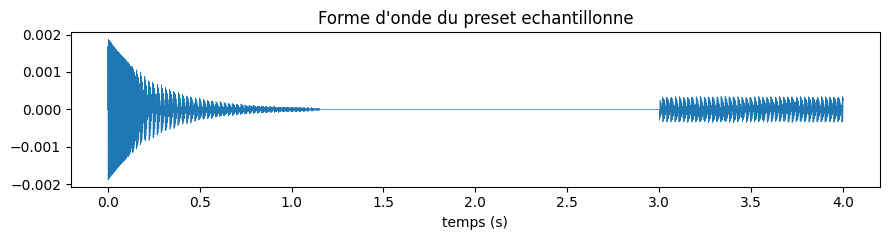

In [4]:
out = system.map({'params': theta})
audio = out['output']
print(f"Audio: {audio.shape}, peak={np.abs(audio).max():.4f}")

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.plot(np.linspace(0, len(audio)/16000, len(audio)), audio, linewidth=0.5)
ax.set_xlabel('temps (s)'); ax.set_title('Forme d\'onde du preset echantillonne')
plt.tight_layout(); plt.show()

display(Audio(audio, rate=16000))

### 2.3 Comportement (`DexedStatistics.map`) -- embedding 38D (6 ACTM + 32 TT)

Attention, cette cellule prend ~10-15s (calcul `ttb` inclus).

In [5]:
import time
t0 = time.time()
z = smap.map(out)
print(f"Calcul de Z: {time.time()-t0:.1f}s\n")

for name, val in zip(Z_FEATURE_NAMES, z['output']):
    print(f"  {name:22s} = {val:.4f}")

(64000,)
[16000]
F_computeDescriptorEnv	0.068412
F_representationFft	0.044515
F_computeDescriptorSpectrum	0.123009
F_computeDescriptorSpectrum	0.123841
F_representationHarmonic	5.732266
F_computeDescriptorHarmonic	0.218243
F_representationERB	1.340906
F_computeDescriptorSpectrum	0.014892
F_computeDescriptorSpectrum	0.015331
Calcul de Z: 11.5s

  ac_hardness            = 42.2905
  ac_depth               = 61.7141
  ac_brightness          = 41.4583
  ac_roughness           = 33.3198
  ac_warmth              = 55.8084
  ac_boominess           = 45.4210
  tt_SpecCent_IQR        = 176.4487
  tt_SpecCrest_med       = 101.4286
  tt_SpecCrest_IQR       = 89.0121
  tt_SpecDecr_med        = 0.0644
  tt_SpecDecr_IQR        = 0.0511
  tt_SpecFlat_med        = 0.0126
  tt_SpecFlat_IQR        = 0.7403
  tt_SpecKurt_med        = 69.9198
  tt_SpecKurt_IQR        = 92.9128
  tt_SpecRollOff_med     = 281.2500
  tt_SpecRollOff_IQR     = 34.7484
  tt_SpecSpread_med      = 235.1150
  tt_SpecSpread_IQR     

### 2.4 Mutation (`mutate()`) -- perturber un preset existant

In [6]:
theta_mutated = pmap.mutate(theta)
preset_mutated = theta_mutated['dynamic_params']['preset']

diffs = sum(1 for (i1, v1), (i2, v2) in zip(preset, preset_mutated) if abs(v1 - v2) > 1e-9)
print(f"{diffs} / {len(preset)} parametres changes par mutate()")

out_mutated = system.map({'params': theta_mutated})
display(Audio(out_mutated['output'], rate=16000))

103 / 155 parametres changes par mutate()


## 3. Charger les decouvertes d'une experience IMGEP

Les experiences sauvegardent chaque decouverte dans un dossier `discoveries/`, avec :
- `discovery.json` (le preset + son embedding Z)
- `config.json`
- `visu.wav` (l'audio rendu, ecoutable directement)

**Note** : `run_500/` a ete lancee AVANT le passage a Z=38D -- ses decouvertes sont encore en
7D (ACTM seul). Le code ci-dessous s'adapte automatiquement a la dimensionnalite trouvee
(voir `visualize_discoveries._dim_names`). Pour une experience en 38D, pointer `RUN_DIR` vers
une experience relancee apres cette mise a jour.

In [7]:
RUN_DIR = ADTOOL_ROOT / 'examples' / 'dexed' / 'run_2000_38D'  # experience en cours (mode 38D complet), a adapter si besoin
DISCOVERIES_DIR = RUN_DIR / 'discoveries'

sys.path.insert(0, str(ADTOOL_ROOT / 'examples' / 'dexed'))
from visualize_discoveries import load_discoveries, _dim_names

Z, order, wav_paths = load_discoveries(DISCOVERIES_DIR)
dim_names = _dim_names(Z.shape[1])
print(f"{len(Z)} decouvertes chargees depuis {DISCOVERIES_DIR}")
print(f"Z shape: {Z.shape} (dims: {dim_names})")

376 decouvertes chargees depuis /u/anasynth/longeot/projects/adtool/examples/dexed/run_500/discoveries
Z shape: (376, 7) (dims: ['hardness', 'depth', 'brightness', 'roughness', 'warmth', 'sharpness', 'boominess'])


### 3.1 Progression de l'exploration dans Z (PCA)

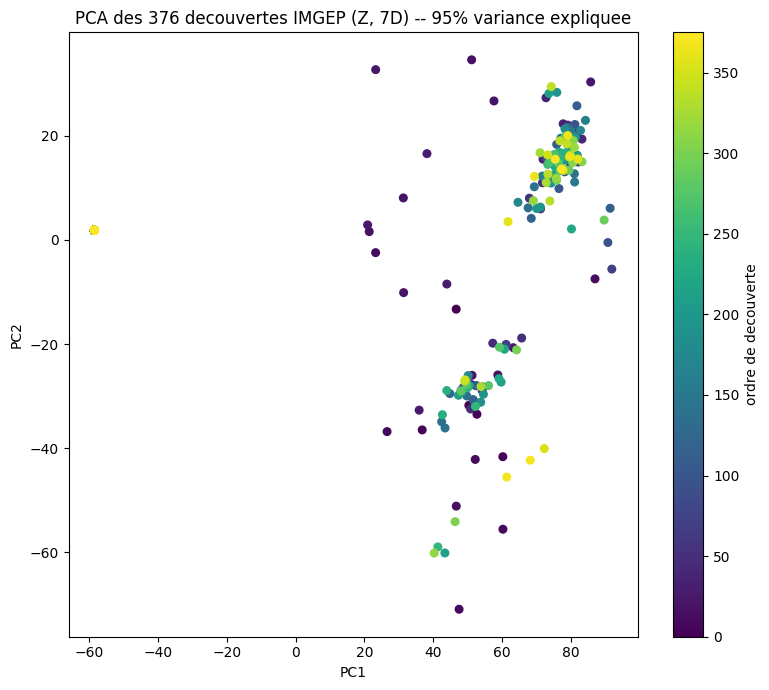

In [8]:
from sklearn.decomposition import PCA

Zc = Z - Z.mean(axis=0)
pca = PCA(n_components=2)
Zp = pca.fit_transform(Zc)

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(Zp[:, 0], Zp[:, 1], c=order, cmap='viridis', s=30)
plt.colorbar(sc, label='ordre de decouverte')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f"PCA des {len(Z)} decouvertes IMGEP (Z, {Z.shape[1]}D) -- "
             f"{100*pca.explained_variance_ratio_.sum():.0f}% variance expliquee")
plt.tight_layout(); plt.show()

On s'attend a voir les points progressivement s'etaler vers des zones nouvelles de
l'espace Z a mesure que l'ordre de decouverte (couleur) augmente -- c'est la signature de la
curiosite : IMGEP ne tire pas au hasard, il vise les zones les moins couvertes.

### 3.2 Structure de Z

Matrice de correlation par paire si Z a peu de dimensions (7D, ACTM seul), ou heatmap de
correlation si Z a beaucoup de dimensions (38D, canonique) -- une matrice de scatter 38x38
serait illisible.

Saved /tmp/tmpdx1mx_u8.png


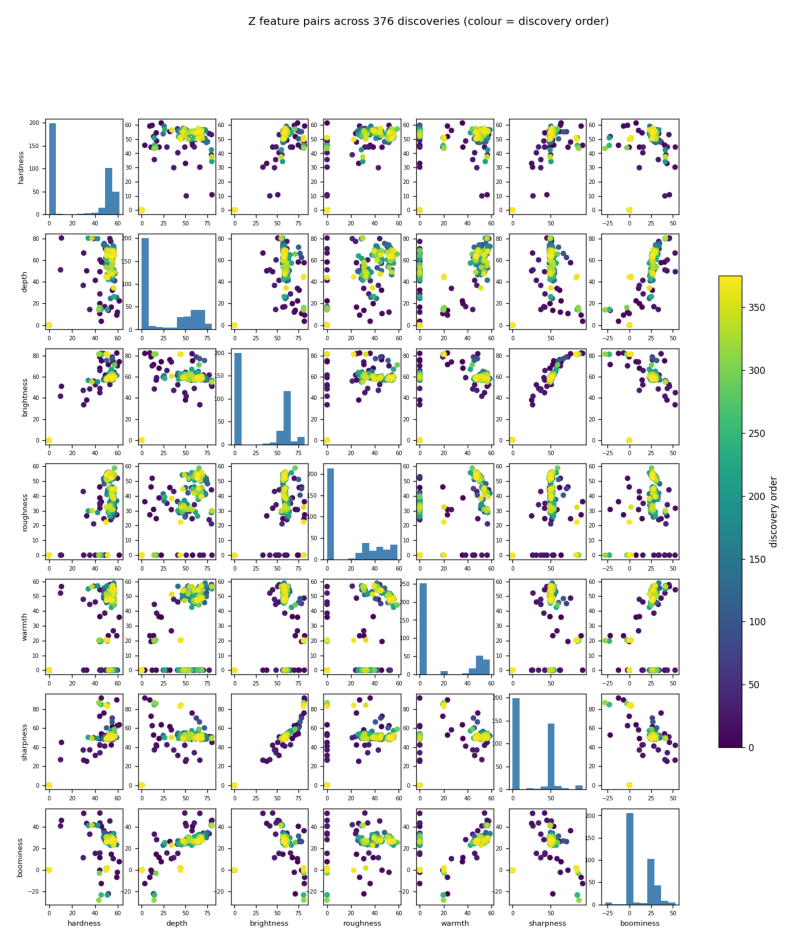

In [9]:
from visualize_discoveries import plot_scatter_matrix
import tempfile

with tempfile.NamedTemporaryFile(suffix='.png') as f:
    plot_scatter_matrix(Z, order, pathlib.Path(f.name), dim_names)
    display_img = plt.imread(f.name)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(display_img); ax.axis('off')
    plt.show()

### 3.3 Metriques de couverture

Si Z est bien en 38D (espace canonique), ces metriques sont **directement comparables** a la
baseline humaine calculee dans `CR audit dataset.md` (meme methodologie : distance moyenne au
plus proche voisin + occupation de grille, en natif). Si Z est en 7D (ACTM seul, anciennes
experiences), la comparaison n'est qu'indicative (espaces differents).

In [10]:
from visualize_discoveries import coverage_metrics

metrics = coverage_metrics(Z)
print(f"--- Couverture IMGEP (espace Z natif, {Z.shape[1]}D) ---")
for k, v in metrics.items():
    print(f"  {k}: {v}")

if Z.shape[1] == 38:
    print("\\n--- Baseline humaine (38D natif, cf. CR audit dataset.md section 2) ---")
    print("  Ratio distance NN dataset humain / uniforme aleatoire : 0.116")
    print("  (comparaison directe possible : meme espace de features)")
else:
    print("\\n--- Cette experience est en 7D (ACTM seul) : pas directement comparable "
          "a la baseline humaine 38D. Relancer une experience apres le passage a Z=38D. ---")

--- Couverture IMGEP (espace Z natif, 7D) ---
  n_discoveries: 376
  mean_nn_distance: 3.3433278693356336
  grid_occupancy: 0.26
  n_bins: 10
\n--- Cette experience est en 7D (ACTM seul) : pas directement comparable a la baseline humaine 38D. Relancer une experience apres le passage a Z=38D. ---


## 4. Ecouter quelques decouvertes

In [11]:
N_LISTEN = 5
sample_idx = np.linspace(0, len(order) - 1, N_LISTEN).astype(int)

for i in sample_idx:
    wav_path = wav_paths[i]
    if wav_path is None:
        continue
    audio_d, sr_d = sf.read(wav_path)
    z_display = dict(zip(dim_names[:6], np.round(Z[i][:6], 1)))
    print(f"Decouverte #{order[i]} -- premieres dims Z = {z_display}")
    display(Audio(audio_d, rate=sr_d))

Decouverte #0 -- premieres dims Z = {'hardness': 61.3, 'depth': 22.4, 'brightness': 74.2, 'roughness': 0.0, 'warmth': 35.8, 'sharpness': 63.5}


Decouverte #93 -- premieres dims Z = {'hardness': 0.0, 'depth': 0.0, 'brightness': 0.0, 'roughness': 0.0, 'warmth': 0.0, 'sharpness': 0.0}


Decouverte #187 -- premieres dims Z = {'hardness': 54.9, 'depth': 60.0, 'brightness': 57.4, 'roughness': 46.1, 'warmth': 52.1, 'sharpness': 49.4}


Decouverte #281 -- premieres dims Z = {'hardness': 0.0, 'depth': 0.0, 'brightness': 0.0, 'roughness': 0.0, 'warmth': 0.0, 'sharpness': 0.0}


Decouverte #375 -- premieres dims Z = {'hardness': 54.6, 'depth': 63.4, 'brightness': 59.0, 'roughness': 52.0, 'warmth': 47.6, 'sharpness': 49.9}


## 5. Etat actuel et prochaines etapes (2026-07-28)

**Fait:**
- `DexedStatistics` calcule desormais le Z=38D complet (6 ACTM + 32 TT via `ttb`), plus
  seulement ACTM (7D) comme dans le premier `run_500`.
- Une premiere experience 38D complete a ete menee (`run_150_38D`, 150 decouvertes).
- Une experience a plus grande echelle est en cours: `run_2000_38D`, 2000 decouvertes visees
  en mode 38D complet (~10-13s/evaluation, soit ~7-8h au total), lancee pour permettre une
  comparaison statistiquement robuste a la baseline humaine.

**A faire:**
- Une fois `run_2000_38D` termine: comparer rigoureusement la couverture IMGEP a la baseline
  humaine avec les memes metriques (grid occupancy, mean NN distance, en 38D natif) -- le
  meme espace de features des deux cotes rend cette comparaison directe.
- Traiter le biais `tt_F0_med` (voir audit dataset, section 5) avant toute analyse qui en
  depend fortement.
- Ecouter/qualifier les decouvertes les plus "extremes" (loin du centre de Z) pour voir si
  IMGEP trouve des sonorites que les presets humains n'explorent pas.
